In [26]:
import pandas as pd
import psychrolib

[1e-07, 0.006213982889463476, 0.006213982889463476, 0.005959709098199538, 0.005522721040231987, 0.006213982889463476, 0.005959709098199538, 0.00575496369542749, 0.00665955778433897, 0.00695283456012741, 0.0069270984169425304, 0.007502212061711614, 0.007209479970661724, 0.007209479970661724, 0.007209479970661724, 0.0069270984169425304, 0.006449288584682134, 0.006173356400409863, 0.005774965165060642, 0.006173356400409863, 0.0059630404543902695, 0.005959709098199538, 0.005959709098199538, 0.0059630404543902695, 0.005538814212385817, 0.005538814212385817, 0.005538814212385817, 0.005524373302715132, 0.005524373302715132, 0.005524373302715132, 0.005538814212385817, 0.0053365606674327945, 0.0053365606674327945, 0.0053365606674327945, 0.0053365606674327945, 0.0053365606674327945, 0.005538814212385817, 0.005538814212385817, 0.0057191286212790555, 0.005959709098199538, 0.006213982889463476, 0.006213982889463476, 0.006213982889463476, 0.00575496369542749, 0.005517584061323754, 0.0052889947122285

<Axes: xlabel='Date'>

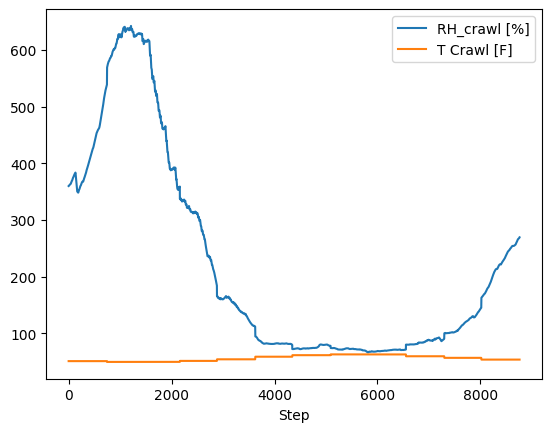

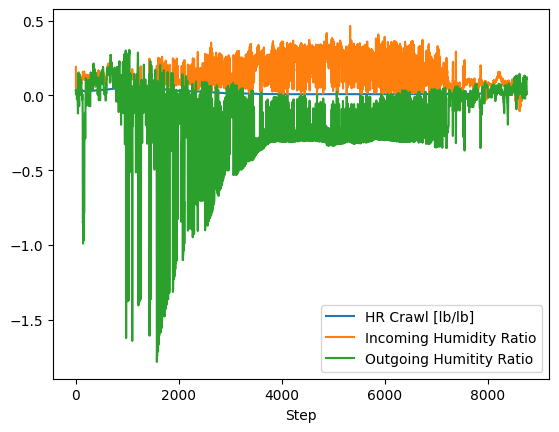

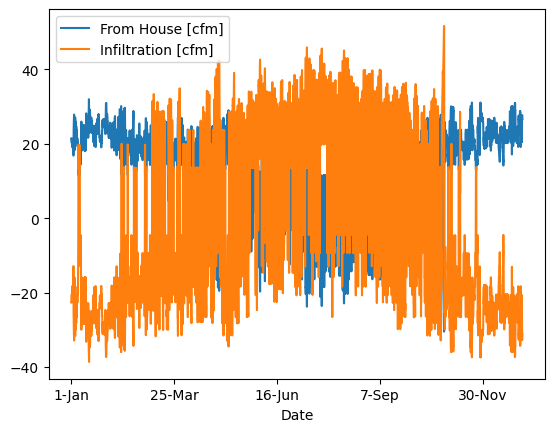

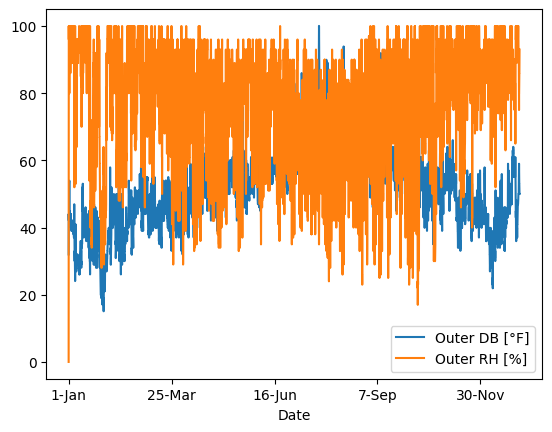

In [37]:
df = pd.read_csv("C:/Users/amitc_crl/Downloads/2743 Hygro CONTAM - 2838.csv")

df.head()

psychrolib.SetUnitSystem(psychrolib.IP)

pressure = psychrolib.GetStandardAtmPressure(580)


DB_out = list(df['Outer DB [°F]'])
RH_out = list(df['Outer RH [%]'])

HR_out = []

for step in range(len(DB_out)):
    HR = psychrolib.GetHumRatioFromRelHum(DB_out[step], (RH_out[step]*0.01), pressure)
    HR_out.append(HR)

print(HR_out)


DB_in = list(df['Indoor DB'])
RH_in = list(df['Indoor RH'])

HR_in = []

for step in range(len(DB_in)):
    HR = psychrolib.GetHumRatioFromRelHum(DB_in[step], (RH_in[step]*0.01), pressure)
    HR_in.append(HR)

print(HR_in)


inf_flow = list(df['Infiltration [cfm]'])
house_flow = list(df['From House [cfm]'])


hr_init = 0.03
crawl_volume = 7500

HR_crawl = []
in_HR= []
out_HR = []

for step in range(len(DB_in)):
    incoming_HR = ((inf_flow[step]*HR_out[step]) + (house_flow[step]*HR_in[step]))
    outgoing_HR = (((inf_flow[step]) + (house_flow[step])) * hr_init)
    hr_crawl = ((crawl_volume*hr_init) + incoming_HR - outgoing_HR)/(crawl_volume)
    hr_init = hr_crawl
    HR_crawl.append(hr_crawl)
    in_HR.append(incoming_HR)
    out_HR.append(-1*outgoing_HR)

print(HR_crawl)

DB_crawl = list(df['Avg Crawl DB [°F]'])

RH_crawl = []

for step in range(len(DB_in)):
    rh_crawl = ((psychrolib.GetRelHumFromHumRatio(DB_crawl[step],HR_crawl[step],pressure))*100)
    RH_crawl.append(rh_crawl)

print(len(RH_crawl))
print(len(list(range(0,8761,1))))

d={'T Crawl [F]':DB_crawl,
   'HR Crawl [lb/lb]':HR_crawl,
   'RH_crawl [%]':RH_crawl,
   'Incoming Humidity Ratio':in_HR,
   'Outgoing Humitity Ratio':out_HR,
   'Step':(list(range(0,8761,1)))}

df2 = pd.DataFrame.from_dict(d)

df2.head()

df2.to_csv('RH crawl output 2838.csv')

df2.plot(x='Step', y=['RH_crawl [%]','T Crawl [F]'] , kind='line')
df2.plot(x='Step', y=['HR Crawl [lb/lb]','Incoming Humidity Ratio','Outgoing Humitity Ratio'] , kind='line')
df.plot(x='Date', y=['From House [cfm]', 'Infiltration [cfm]'], kind='line')
df.plot(x='Date', y=['Outer DB [°F]', 'Outer RH [%]'], kind='line')